In [3]:
import numpy as np
import matplotlib.pyplot as plt

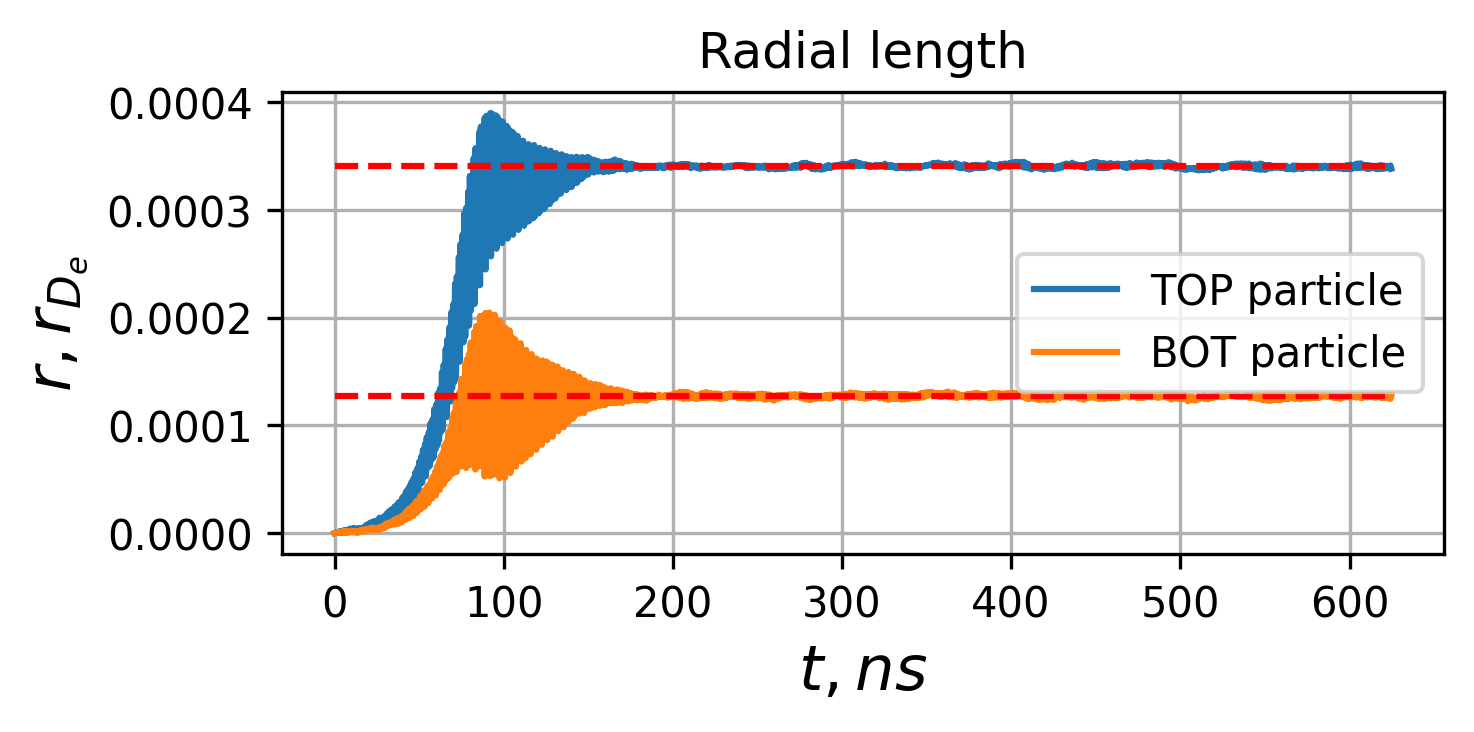

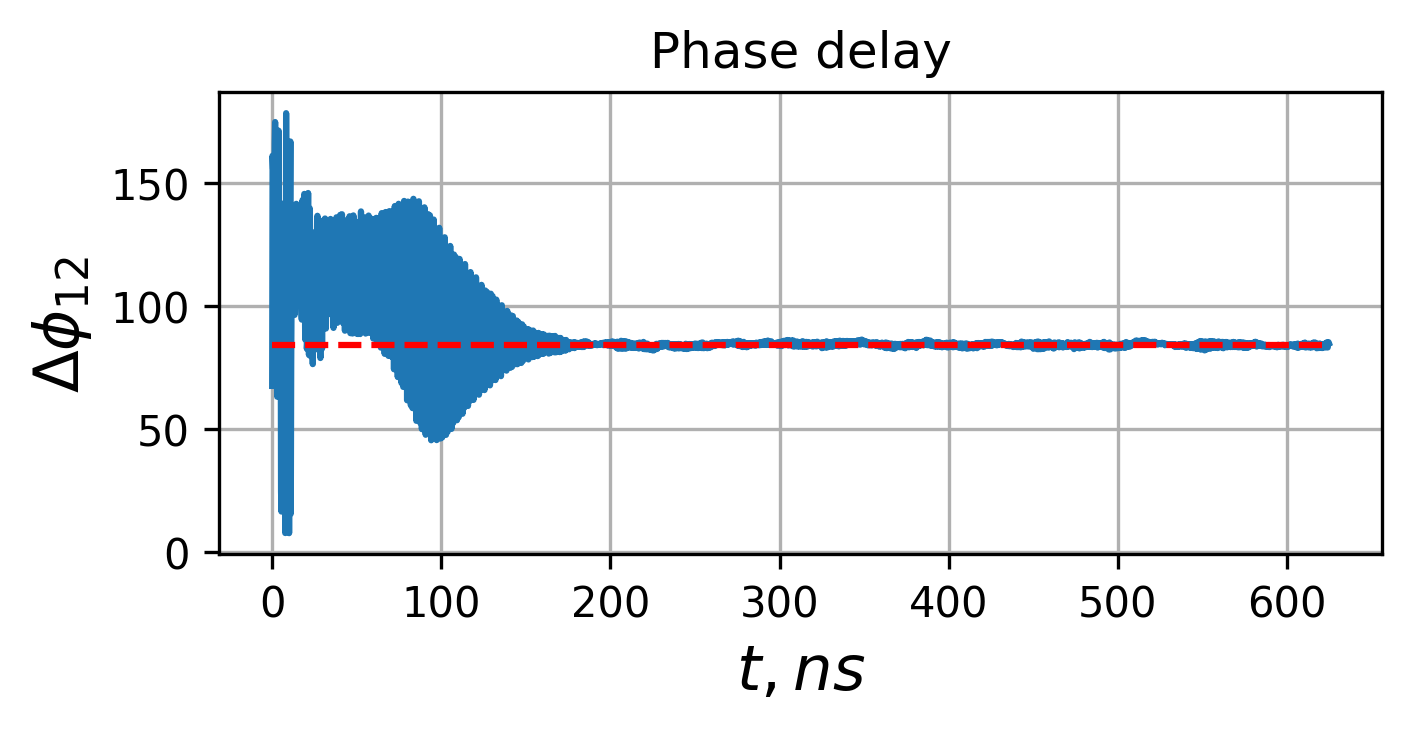

In [10]:
data = np.genfromtxt(f"../data/dynamics/data.txt", delimiter="\t")

rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))
zs_1 = data[:, 3]
vzs_1 = data[:, 6]

vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))
zs_2 = data[:, 9]
vzs_2 = data[:, 12]

t = (data[:, 0]) / 2.0 * 50.0
t_min = np.min(t)
t_max = np.max(t)

k_B = 1.380649e-23  # Boltzmann constant (J/K)
m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
P = 0.25 * 18.131842  # Pressure (Pascal)
r_D_e = 0.0016622715189364113

dphis = []
for i in range(len(data[:, 1])):
    dphis += [
        np.dot(
            np.array([data[i, 1], data[i, 2]]),
            np.array([data[i, 4], data[i, 5]]),
        )
        / rs_1[i]
        / rs_2[i]
    ]
dphis = np.array(dphis)
dphis = np.arccos(-dphis) * 57

# r1 & r2
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"Radial length")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$r, r_{D_e}$", fontsize=15)
plt.grid()
plt.plot(t, rs_1, "-", label="TOP particle")
plt.plot(t, rs_2, "-", label="BOT particle")
plt.hlines(
    np.mean(rs_1[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
)
plt.hlines(
    np.mean(rs_2[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
)
plt.legend(loc="best")
plt.show()

# delta phi
plt.figure(dpi=300, figsize=(5, 2))
plt.title(f"Phase delay")
plt.xlabel(r"$t, ns$", fontsize=15)
plt.ylabel(r"$\Delta \phi_{12}$", fontsize=15)
plt.grid()
plt.plot(t, dphis, "-")
plt.hlines(
    np.mean(dphis[1_000:]),
    1.1 * t_min,
    t_max,
    linestyles="--",
    colors="red",
)
plt.show()